In [4]:
setwd("/well/lindgren-ukbb/projects/ukbb-11867/flassen/projects/KO/wes_ko_ukbb")
library(data.table)
library(ggplot2)


## THIS SCRIPT HAS NOW BEEN CONVERTED INTO A SHELL SCRIPT.

In [35]:
d <- fread("data/post_hoc//results//pLoF_damaging_missense_maf0to5e-2_survival_knockouts_by_phenotypes.txt.gz")
bool <- d$CHET_TRANS > 15
d <- d[bool,]
d <- melt(d[,1:6], id.vars = "phenotype")
#d$logcount <- log10(d$value)

In [36]:
sci10 <- function(x) {
  parse(text=gsub("e", " %*% 10^", scales::scientific_format()(x)))
}

In [37]:
head(d)

phenotype,variable,value
<chr>,<fct>,<int>
Abdominal Hernia,CHET_CIS,4191
Abdominal aortic aneurysm,CHET_CIS,100
Acne,CHET_CIS,330
Actinic keratosis,CHET_CIS,1828
Acute Kidney Injury,CHET_CIS,321
Agranulocytosis,CHET_CIS,172


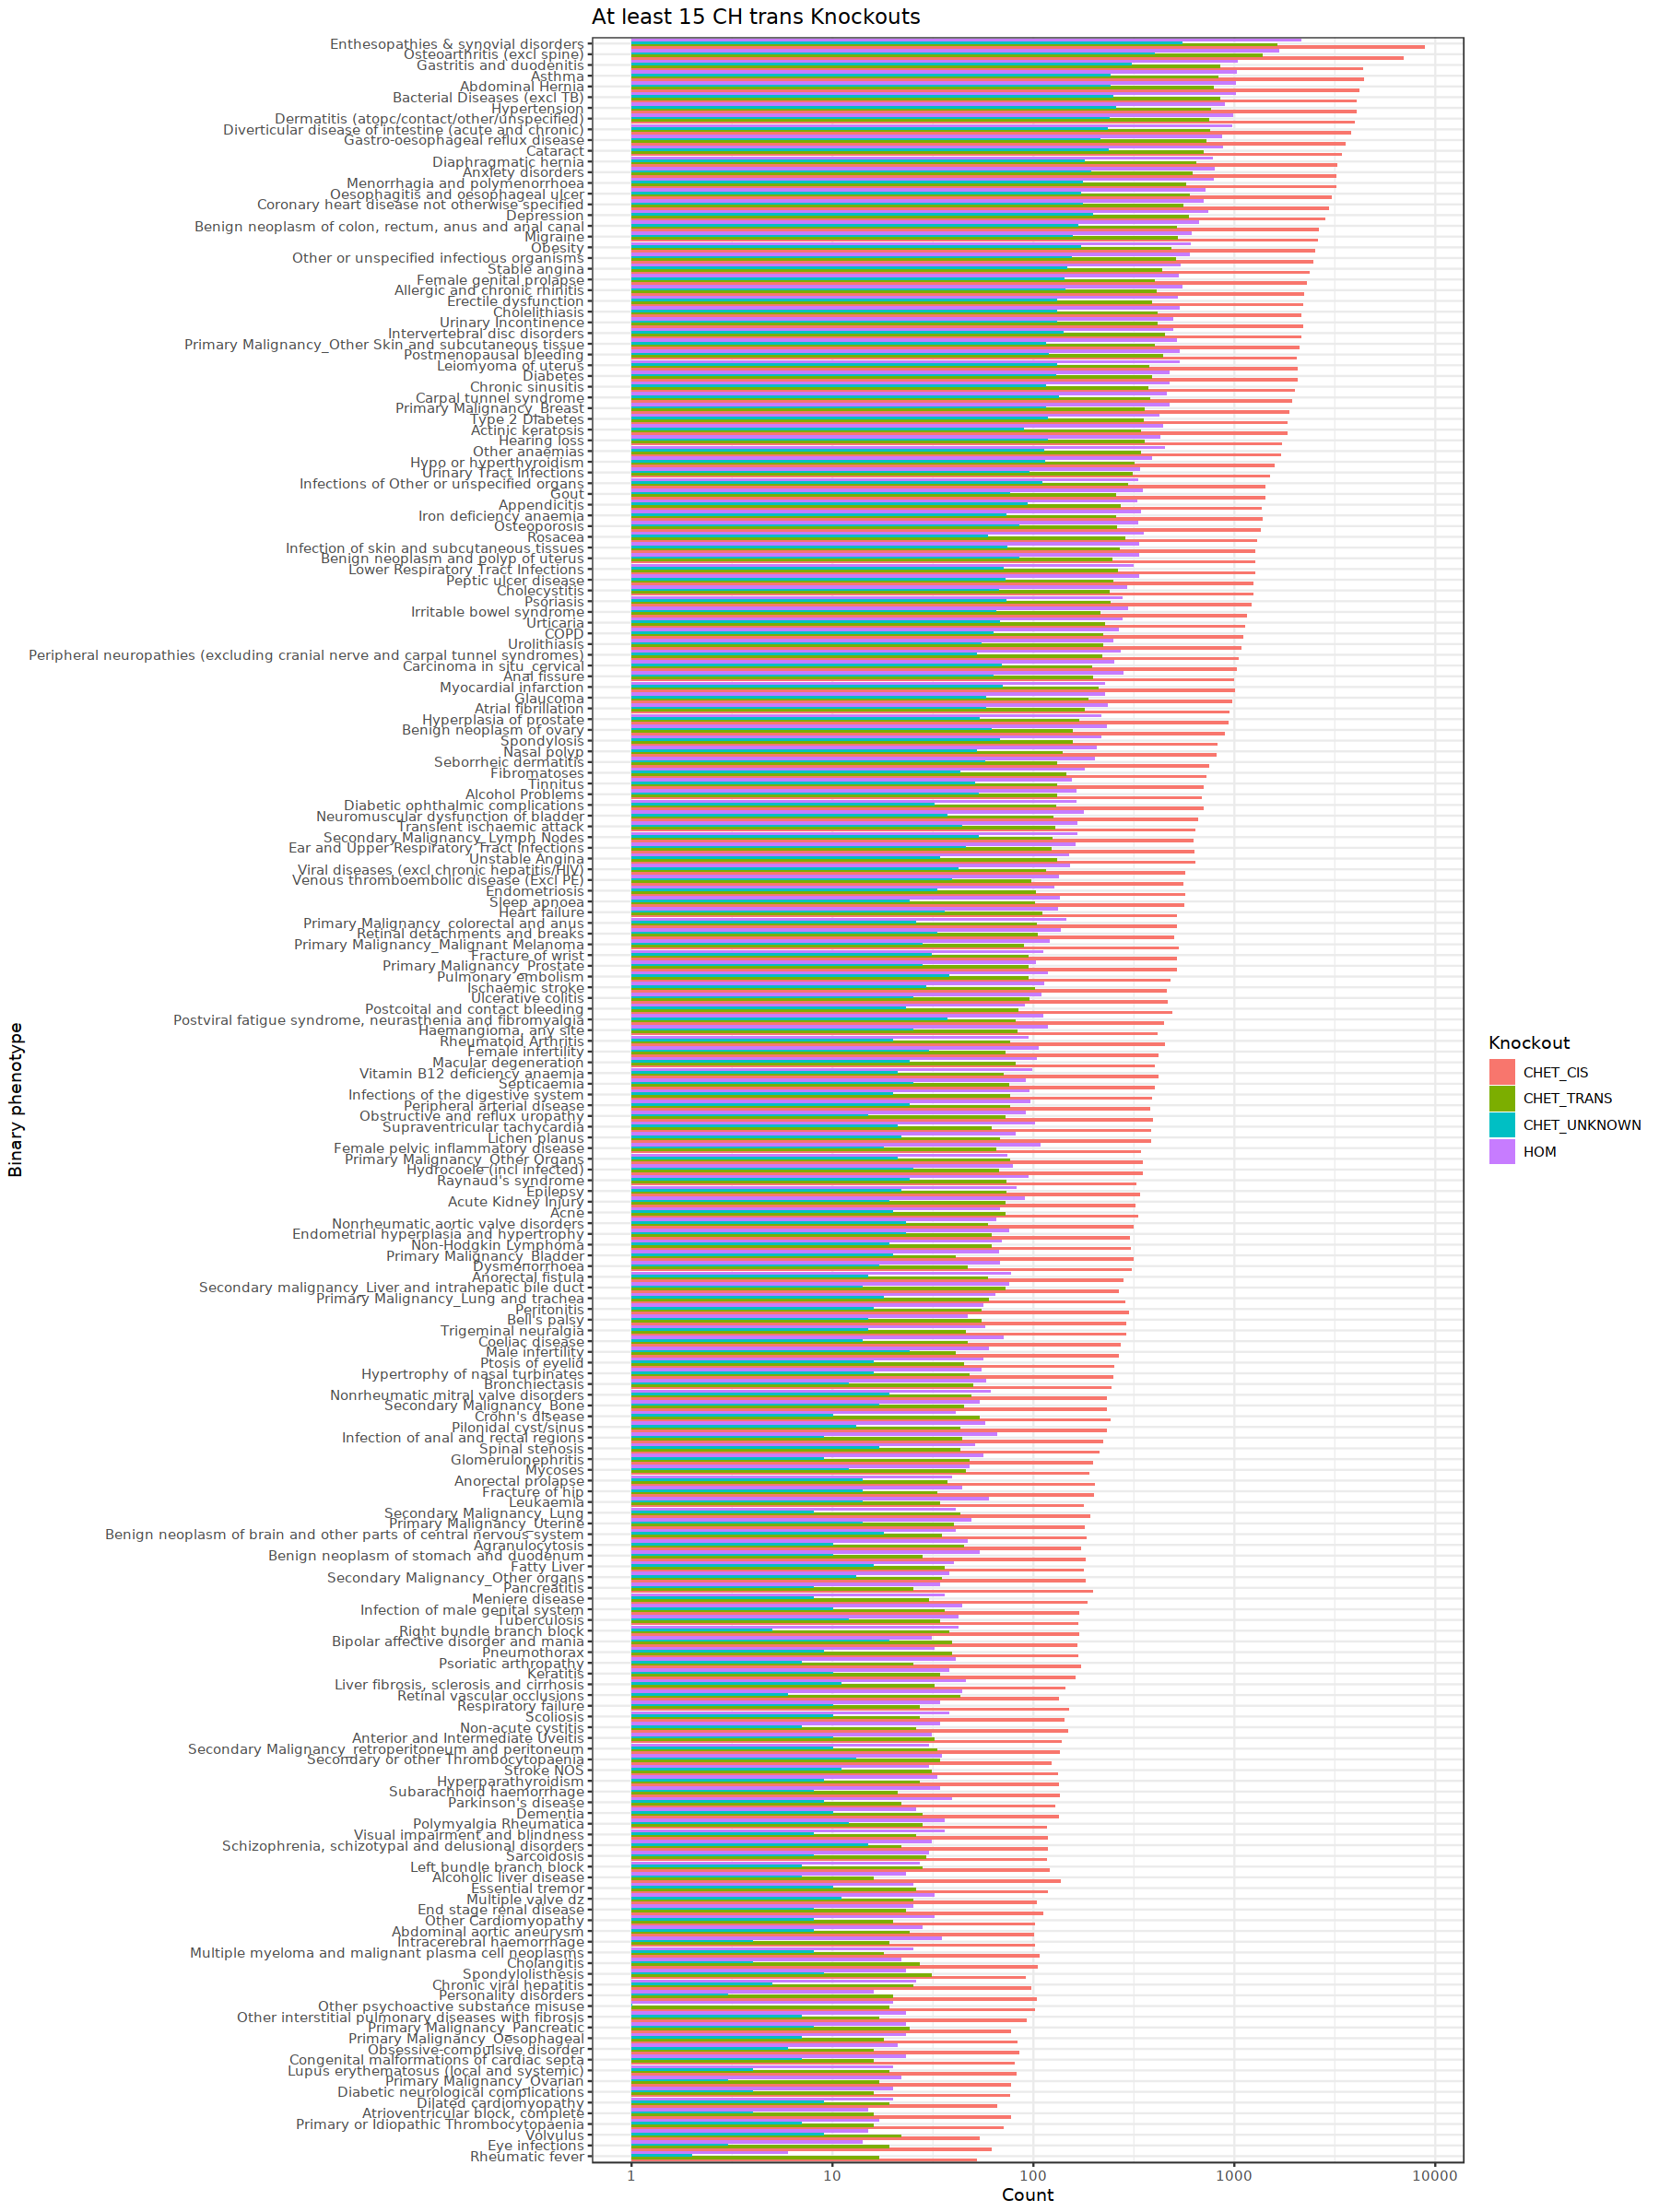

In [41]:
options(scipen=10000)
options(repr.plot.width=15, repr.plot.height=20)
ggplot(d[d$variable != "HET"], aes(y=reorder(phenotype, value), x = value, group = variable, fill = variable)) +
    geom_bar(stat = "identity", position="dodge") +
    scale_x_continuous(trans='log10') +
    xlab("Count") + 
    ylab('Binary phenotype') +
    labs(fill = "Knockout") +
    theme_bw() + 
    ggtitle("At least 15 CH trans Knockouts")

In [42]:
d <- fread("data/post_hoc//results//pLoF_damaging_missense_maf0to5e-2_survival_knockouts_by_phenotypes.txt.gz")


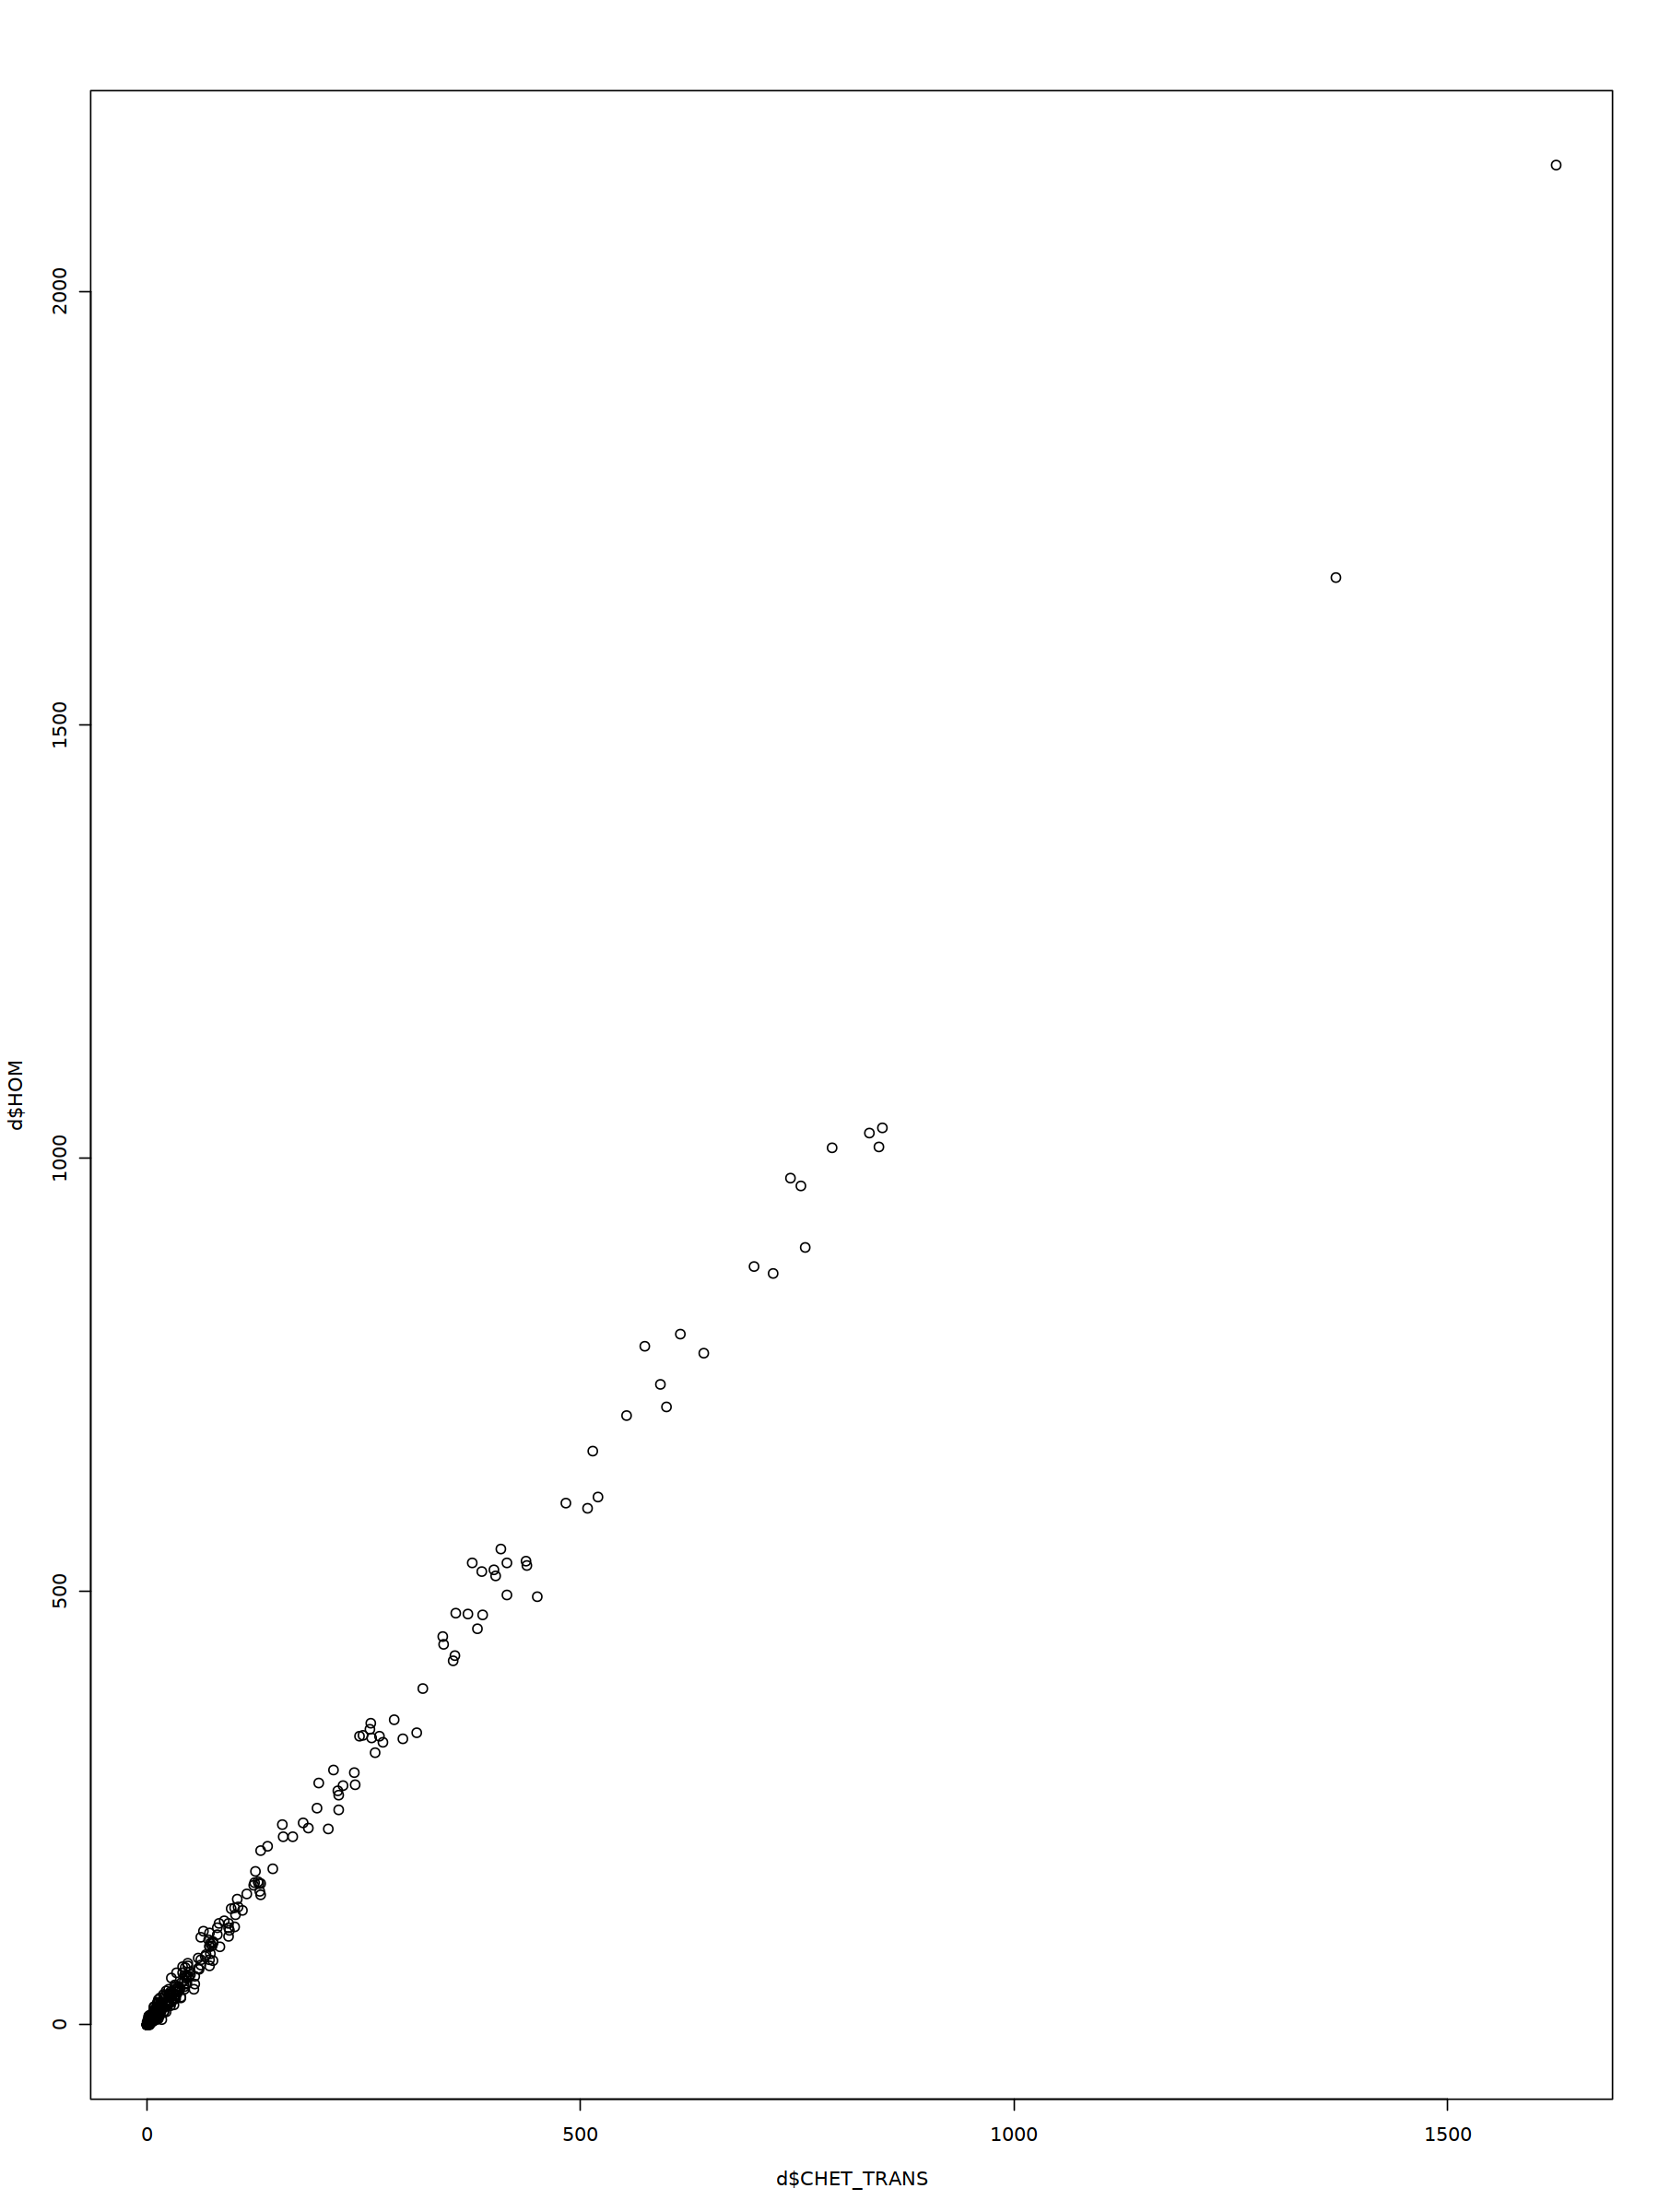

In [43]:
plot(d$CHET_TRANS, d$HOM)

In [44]:
d

phenotype,CHET_CIS,CHET_TRANS,CHET_UNKNOWN,HET,HOM,phenos_na,cases_all,controls_all
<chr>,<int>,<int>,<int>,<int>,<int>,<int>,<int>,<int>
Abdominal Hernia,4191,790,241,440512,1012,144724,4,0
Abdominal aortic aneurysm,100,24,8,9659,28,156559,0,0
Acne,330,72,20,36318,68,155824,0,0
Actinic keratosis,1828,342,89,185396,439,151734,0,0
Acute Kidney Injury,321,72,19,33820,90,155901,0,0
Agranulocytosis,172,45,10,19482,47,156289,0,0
Alcohol Problems,685,131,53,75990,163,154742,0,0
Alcoholic liver disease,136,16,7,13017,23,156469,0,0
Allergic and chronic rhinitis,2218,408,143,227393,549,150566,0,0
